In [1]:
# imports
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import scipy.stats as stats

# Loading in the Data

In [2]:
YCRDataPreparedFilepath = '../data/FinalCleanYelpData.csv'

In [3]:
YCRDataPrepared = pd.read_csv(YCRDataPreparedFilepath)
YCRDataPrepared

,Name,Latitude,Longitude,Distance,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Category,Rounded Latitude,Rounded Longitude,Rounded Distance,Rounded Distance_mean
0,Ravintola Vinkkeli,60.163900,24.946410,993.930059,Most Expensive,5.0,652.820553,104.417207,993.930059,28,Modern European,60.164,24.946,993.930,652.821
1,Baskeri & Basso,60.157873,24.934694,906.269559,Affordable,4.8,673.116165,83.377593,978.824142,16,Bistros,60.158,24.935,906.270,673.116
2,Chef & Sommelier,60.157660,24.942540,489.112498,Most Expensive,4.8,641.800023,134.034975,943.511457,14,Scandinavian,60.158,24.943,489.112,641.800
3,Spis,60.163631,24.947679,910.667273,Most Expensive,4.8,636.883659,122.448928,951.268827,24,Scandinavian,60.164,24.948,910.667,636.884
4,Ani,60.157150,24.933661,941.072231,Affordable,4.5,718.839949,163.361331,995.254401,16,Turkish,60.157,24.934,941.072,718.840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9730,Karhu Ministeri,60.189571,24.917259,705.595387,Affordable,3.3,511.016285,192.545596,902.743177,11,Pubs,60.190,24.917,705.595,511.016
9731,Ravintola Lehtovaara,60.183600,24.915930,542.047402,Most Expensive,3.3,592.193958,190.699671,961.362096,9,Scandinavian,60.184,24.916,542.047,592.194
9732,Boatip,60.184929,24.941851,891.112679,Most Affordable,4.0,858.743008,826.373336,891.112679,2,Thai,60.185,24.942,891.113,858.743
9733,Diyalo,60.184676,24.923223,125.893234,Affordable,4.0,527.561874,125.893234,909.115155,7,Himalayan/Nepalese,60.185,24.923,125.893,527.562


# Building a regression model

In [4]:
# X are features Y is target.
X_Numeric = YCRDataPrepared[['Rounded Latitude','Rounded Longitude','Rating','Rounded Distance','Rounded Distance_mean']]
y = YCRDataPrepared['Bike Spots Near']

In [5]:
X_Numeric

,Rounded Latitude,Rounded Longitude,Rating,Rounded Distance,Rounded Distance_mean
0,60.164,24.946,5.0,993.930,652.821
1,60.158,24.935,4.8,906.270,673.116
2,60.158,24.943,4.8,489.112,641.800
3,60.164,24.948,4.8,910.667,636.884
4,60.157,24.934,4.5,941.072,718.840
...,...,...,...,...,...
9730,60.190,24.917,3.3,705.595,511.016
9731,60.184,24.916,3.3,542.047,592.194
9732,60.185,24.942,4.0,891.113,858.743
9733,60.185,24.923,4.0,125.893,527.562


In [6]:
y

0       28
1       16
2       14
3       24
4       16
        ..
9730    11
9731     9
9732     2
9733     7
9734     5
Name: Bike Spots Near, Length: 9735, dtype: int64

In [7]:
# checking for correlation.
CorrelationMatrix = YCRDataPrepared.corr(numeric_only=True)
CorrelationMatrix

,Latitude,Longitude,Distance,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Rounded Latitude,Rounded Longitude,Rounded Distance,Rounded Distance_mean
Latitude,1.000000,0.332180,-0.072395,-0.291110,-0.225244,-0.141155,-0.127531,-0.136595,0.999970,0.332266,-0.072395,-0.225244
Longitude,0.332180,1.000000,0.010182,0.060689,0.031680,0.058445,-0.086827,0.015129,0.331948,0.999994,0.010182,0.031680
Distance,-0.072395,0.010182,1.000000,0.045317,0.321408,0.216417,0.147196,-0.024512,-0.072384,0.010194,1.000000,0.321408
Rating,-0.291110,0.060689,0.045317,1.000000,0.140995,0.000661,0.173716,0.416197,-0.291520,0.060767,0.045317,0.140995
Distance_mean,-0.225244,0.031680,0.321408,0.140995,1.000000,0.673341,0.457971,-0.076264,-0.225208,0.031717,0.321408,1.000000
Distance_min,-0.141155,0.058445,0.216417,0.000661,0.673341,1.000000,-0.090176,-0.394952,-0.141270,0.058352,0.216417,0.673340
Distance_max,-0.127531,-0.086827,0.147196,0.173716,0.457971,-0.090176,1.000000,0.380365,-0.127487,-0.086773,0.147196,0.457971
Bike Spots Near,-0.136595,0.015129,-0.024512,0.416197,-0.076264,-0.394952,0.380365,1.000000,-0.136525,0.015216,-0.024512,-0.076264
Rounded Latitude,0.999970,0.331948,-0.072384,-0.291520,-0.225208,-0.141270,-0.127487,-0.136525,1.000000,0.332035,-0.072384,-0.225208
Rounded Longitude,0.332266,0.999994,0.010194,0.060767,0.031717,0.058352,-0.086773,0.015216,0.332035,1.000000,0.010194,0.031717


In [14]:
# showing if anything has high correlation. 0.7 is the threshold
def HighlyCorrelatedFeatures(CorrelationMatrix):
    '''
    Identify all feature combinations that have high (0.7 or greater) correlation.
    Args:
    CorrelationMatrix (DataFrame): the correlation matrix of the data that is being interpreted.

    Returns:
    A DataFrame containing three columns with all feature combinations that are highly correlated.
    Feature 1 is the first of the 2 features that are highly correlated.
    Feature 2 is the second of the 2 features that are highly correlated.
    Correlation contains the correlation of the two features from the correlation matrix.

    '''
    # creating a dictionary to store any pairs
    HighCorr = {}

    # Iterate over the correlation matrix
    for i in range(len(CorrelationMatrix.columns)):
        for j in range(i+1, len(CorrelationMatrix.columns)):  # avoiding duplicate pairs
            Feature1 = CorrelationMatrix.columns[i]
            Feature2 = CorrelationMatrix.columns[j]
            CorrValue = CorrelationMatrix.iloc[i, j]

            if abs(CorrValue) > 0.7:
                HighCorr[(Feature1, Feature2)] = CorrValue


    # converting into a dataframe
    HighCorrelation = pd.DataFrame(
        [(k[0], k[1], v) for k, v in HighCorr.items()],
        columns=["Feature 1", "Feature 2", "Correlation"]
    )

    return HighCorrelation

In [10]:
HighlyCorrelatedFeatures(CorrelationMatrix)

,Feature 1,Feature 2,Correlation
0,Latitude,Rounded Latitude,0.999970
1,Longitude,Rounded Longitude,0.999994
2,Distance,Rounded Distance,1.000000
3,Distance_mean,Rounded Distance_mean,1.000000


The closer a value is to 1, the more correlated. There are no codependency issues here. The high correlations shown here are between values and their rounded counterparts.

In [5]:
# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X_Numeric,y, test_size=0.2, random_state=42)

## streamlining model

In [10]:
def ExplanationAndErrors(Model, X, y):
    '''
    Makes calculations to determine how much a model explains and how much error it has.

    Args:
        Model (model): the model used to make predictions.
        X (dataframe): the features used to make the prediction. either training or testing.
        y (series): the actual target values that match up with the features. either training or testing. compared against y_pred.
    '''
    y_pred = Model.predict(X)

    # calculating R^2 (Coefficient of Determination)
    ModelR2 = r2_score(y,y_pred)
    print(f'R^2: {ModelR2}')
    
    # adjusted R^2
    ModelAdjR2 = 1-(((1-ModelR2)*(len(X)-1))/(len(X)-len(X.columns)-1))
    print(f'Adjusted R^2: {ModelAdjR2}')

    # evaluating the model
    ModelMSE = mean_squared_error(y, y_pred)
    print(f'Mean Squared Error: {ModelMSE}')
    # getting RMSE to have more interpretability 
    ModelRMSE = np.sqrt(ModelMSE)
    print(f'Root Mean Squared Error: {ModelRMSE}')
    return ModelR2, ModelAdjR2, ModelMSE, ModelRMSE

In [ ]:
# putting code for categorical model into function

In [ ]:
def ModelCalculations(Model, BetaHat, X, y):
    '''
    Makes calculations about a linear regression model to be used in interpreting the predictive power of the model.

    Args:
        Model (linear regression model): the linear regression model used to make predictions
        BetaHat (float): the coefficients from the trained model
        X (dataframe): the features used to make the prediction. either training or testing.
        y (series): the actual target values that match up with the features. either training or testing. compared against y_pred

    Returns:
        Calculations that can be used to interpret the model's performance both on the training data and on the testing data.
    '''

    # calculating standard errors on the test set
    y_pred = Model.predict(X)
    Residuals = y - y_pred
    SSE = np.sum(Residuals**2)
    ResidualsDegreesOfFreedom = len(y) - len(BetaHat)

    # getting variance-covariance matrix
    X_Inverse = np.linalg.inv(X.T @ X)
    VarianceBeta = SSE / ResidualsDegreesOfFreedom * X_Inverse
    StandarErrorsBeta = np.sqrt(np.diag(VarianceBeta))

    # computing t-statistics
    tStatistics = BetaHat / StandarErrorsBeta

    # computing p-values
    pValues = 2 * stats.t.sf(np.abs(tStatistics), df=ResidualsDegreesOfFreedom)
    
    # computing RSS and TSS
    ResSumSq = np.sum((y - y_pred)**2)  # Residual Sum of Squares
    TotSumSq = np.sum((y - np.mean(y))**2)  # Total Sum of Squares

    # Degrees of freedom
    p = X.shape[1] - 1  # Number of predictors
    n = X.shape[0]  # Number of observations
    DegreesFreedomModel = p
    DegreesFreedomResidual = n - p - 1

    # computing F-statistic
    fStatistic = ((TotSumSq - ResSumSq) / DegreesFreedomModel) / (ResSumSq / DegreesFreedomResidual)

    # computing p-value for F-statistic
    fStatpVal = 1 - stats.f.cdf(fStatistic, DegreesFreedomModel, DegreesFreedomResidual)
    
    # showing results
    for i, (coef, se, t, p) in enumerate(zip(BetaHat, StandarErrorsBeta, tStatistics, pValues)):
        print(f"Coefficient {i}: β={coef:.4f}, SE={se:.3f}, t={t:.3f}, P>|t|={p:.3f}")

    print(f"F-statistic: {fStatistic:.3f}, Prob(F-statistic): {fStatpVal:.3f}")

In [ ]:
def LinearRegressionModel(X_train, X_test, y_train, y_test):
    '''
    Takes the split training and testing data. Trains an Ordinary Least Squares model. Displays calculations that can be used to interpret the model's performance both on the training data and on the testing data.
    
    Args:
        X_train (DataFrame): To be used to train the model. The numerical features used to try to predict the specified target.
        X_test (DataFrame): To be used to test the model. The numerical features used to try to predict the specified target.
        y_train (DataFrame): To be used to train the model. The specified target that the model is trying to predict.
        y_test (DataFrame): To be used to test the model. The specified target that the model is trying to predict.


    Returns:
        Calculations that can be used to interpret the model's performance both on the training data and on the testing data.
    '''
    # adding a constant
    X_train = sm.add_constant(X_train)
    X_test = sm.add_constant(X_test)
    
    # setting up the model
    LinReg = sm.OLS(y_train, X_train)
    
    # fitting the model
    Model = LinReg.fit()
    
    # displaying the model summary that has information on how the model performs on the training data
    ModelOutput = Model.summary()
    print(ModelOutput)
    
    # getting coefficients from the trained model
    BetaHat = Model.params

    print(f'Showing calculations made with X_train and y_train')
    training_fit = ExplanationAndErrors(Model, X_train, y_train)
    print(training_fit)
    training_output = ModelCalculations(Model, BetaHat, X_train, y_train)
    print(training_output)

    print(f'Showing calculations made with X_test and y_test')
    testing_fit = ExplanationAndErrors(Model, X_test, y_test)
    print(testing_fit)
    testing_ouput = ModelCalculations(Model, BetaHat, X_test, y_test)
    print(testing_ouput)


In [32]:
ModelOutput1 = LinearRegressionModel(X_train, X_test, y_train, y_test)
ModelOutput1

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     367.3
Date:                Tue, 06 May 2025   Prob (F-statistic):               0.00
Time:                        16:46:41   Log-Likelihood:                -26254.
No. Observations:                7788   AIC:                         5.252e+04
Df Residuals:                    7782   BIC:                         5.256e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   495.23

## Model Output and Interpretation
---

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
    <th>Prob (F-statistic)
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
    <td>
      <p>Null hypothesis: a model made with only the constant coefficient value of 495.2383 is equal to this model made with the <span class='feature'>features Rounded Latitude</span>, <span class='feature'>Rounded Longitude</span>, <span class='feature'>Rating</span>, <span class='feature'>Rounded Distance</span>, and <span class='feature'>Rounded Distance_mean</span>.
      </p>
      <p>Reject null hypothesis: Prob (F-statistic) < 0.05
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.203
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.190
            </td>
            <td>0.200
            </td>
          </tr>
        </table>
      </div>
        <p>The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>49.615
            </td>
            <td>52.256
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>7.044
          </td>
          <td>7.229
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>
          The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
    </td>
    <td rowspan>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.00
          </td>
          <td>0.00
          </td>
        </tr>
      </table>
        <p>
        </p>
      We can reject the null hypothesis and accept the alternate hypothesis that the model only using the constant coefficient value of 495.2383 is worse than this model made with the <span class='feature'>features</span> Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Feature Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>P>|t|
    </th>
    <th>Coefficient
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
    </td>
    <td>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td class='lower center'>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <table class='SplitRow'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.000
          </td>
          <td>0.083
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>
      <p>As explained by the R-squared, adjusted R-squared, and p-values in the case of Rounded Latitude, Rounded Longitude, and Rounded Distance, the <span class='feature'>features</span> likely don't actually have any effect on the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>. 
      </p>
      <p>Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.
      <p>
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Latitude
      </span>
    </td>
    <td class='center'>
      <table class='SplitRow'>
        <tr>
          <td>0.001
          </td>
          <td>0.096
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>-8.3100
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Longitude
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.596
          </td>
          <td>0.799
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>+0.5343
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rating
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>+3.5630
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.741
          </td>
          <td>0.871
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>-0.0001
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance_mean
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>-0.0132
    </td>
  </tr>
</table>

## Adjustment 1

In [8]:
# adjusting the model by removing the feature with the highest p-value. also adjusting the test data to work with this change.
X_trainAdjusted = X_train.drop(columns=['Rounded Distance'])
X_testAdjusted = X_test.drop(columns=['Rounded Distance'])
print(f'total columns in X_trainAdjusted = total columns in X_testAdjusted: {len(X_trainAdjusted.columns) == len(X_testAdjusted.columns)}')

total columns in X_trainAdjusted = total columns in X_testAdjusted: True


In [9]:
ModelAdjusted = LinearRegressionModel(X_trainAdjusted, X_testAdjusted, y_train, y_test)
ModelAdjusted

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     459.2
Date:                Sat, 10 May 2025   Prob (F-statistic):               0.00
Time:                        10:58:51   Log-Likelihood:                -26254.
No. Observations:                7788   AIC:                         5.252e+04
Df Residuals:                    7783   BIC:                         5.255e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   495.52

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
    <th>Prob (F-statistic)
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
    <td>
      <p>Null hypothesis: a model made with only the constant coefficient value of 495.5222 is equal to this model made with the <span class='feature'>features Rounded Latitude</span>, <span class='feature'>Rounded Longitude</span>, <span class='feature'>Rating</span>, <span class='feature'>Rounded Distance</span>, and <span class='feature'>Rounded Distance_mean</span>.
      </p>
      <p>Reject null hypothesis: Prob (F-statistic) < 0.05
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.203
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.201
          </tr>
        </table>
      </div>
        <p>The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>49.616
            </td>
            <td>52.250
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>7.044
          </td>
          <td>7.228
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>
          The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
    </td>
    <td rowspan>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.00
          </td>
          <td>0.00
          </td>
        </tr>
      </table>
        <p>
        </p>
      We can reject the null hypothesis and accept the alternate hypothesis that the model only using the constant coefficient value of 495.5222 is worse than this model made with the <span class='feature'>features</span> Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Feature Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>P>|t|
    </th>
    <th>Coefficient
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
    </td>
    <td>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td class='lower center'>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <table class='SplitRow'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.000
          </td>
          <td>0.082
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>
      <p>As explained by the R-squared, adjusted R-squared, and p-values in the case of Rounded Latitude, Rounded Longitude, and Rounded Distance, the <span class='feature'>features</span> likely don't actually have any effect on the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>. 
      </p>
      <p>Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.
      <p>
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Latitude
      </span>
    </td>
    <td class='center'>
      <table class='SplitRow'>
        <tr>
          <td>0.001
          </td>
          <td>0.095
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>-8.3148
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Longitude
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.596
          </td>
          <td>0.799
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>+0.5346
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rating
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>+3.5631
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance_mean
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>-0.0133
    </td>
  </tr>
</table>

## Adjustment 2

In [9]:
# adjusting the model by removing the feature with the highest p-value. also adjusting the test data to work with this change.
X_trainAdjusted2 = X_trainAdjusted.drop(columns=['Rounded Longitude'])
X_testAdjusted2 = X_testAdjusted.drop(columns=['Rounded Longitude'])
print(f'total columns in X_trainAdjusted2 = total columns in X_testAdjusted2: {len(X_trainAdjusted2.columns) == len(X_testAdjusted2.columns)}')

total columns in X_trainAdjusted2 = total columns in X_testAdjusted2: True


In [11]:
ModelAdjusted2 = LinearRegressionModel(X_trainAdjusted2, X_testAdjusted2, y_train, y_test)
ModelAdjusted2

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     612.2
Date:                Sun, 11 May 2025   Prob (F-statistic):               0.00
Time:                        11:11:50   Log-Likelihood:                -26254.
No. Observations:                7788   AIC:                         5.252e+04
Df Residuals:                    7784   BIC:                         5.254e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   479.58

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
    <th>Prob (F-statistic)
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
    <td>
      <p>Null hypothesis: a model made with only the constant coefficient value of 479.5840 is equal to this model made with the <span class='feature'>features Rounded Latitude</span>, <span class='feature'>Rounded Longitude</span>, <span class='feature'>Rating</span>, <span class='feature'>Rounded Distance</span>, and <span class='feature'>Rounded Distance_mean</span>.
      </p>
      <p>Reject null hypothesis: Prob (F-statistic) < 0.05
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.203
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.201
          </tr>
        </table>
      </div>
        <p>The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>49.618
            </td>
            <td>52.267
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>7.044
          </td>
          <td>7.230
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
        <p>The MSE has increased after removing Rounded Longitude as a <span class='feature'>feature</span>. With that said, the t-test is a clearer indication of a <span class='feature'>feature's</span> relevance to the model.
        </p>
    </td>
    <td rowspan>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.00
          </td>
          <td>0.00
          </td>
        </tr>
      </table>
        <p>
        </p>
      We can reject the null hypothesis and accept the alternate hypothesis that the model only using the constant coefficient value of 479.5840 is worse than this model made with the <span class='feature'>features</span> Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Feature Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>P>|t|
    </th>
    <th>Coefficient
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
    </td>
    <td>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td class='lower center'>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <table class='SplitRow'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.000
          </td>
          <td>0.086
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>
      <p>As explained by the R-squared, adjusted R-squared, and p-values in the case of Rounded Latitude, Rounded Longitude, and Rounded Distance, the <span class='feature'>features</span> likely don't actually have any effect on the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>. 
      </p>
      <p>Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.
      <p>
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Latitude
      </span>
    <td class='center'>
      <table class='SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.091
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>-7.8297
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rating
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>+3.5714
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance_mean
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>-0.0133
    </td>
  </tr>
</table>

## Adjustment 3

In [10]:
# adjusting the model by removing the feature with the highest p-value. also adjusting the test data to work with this change.
X_trainAdjusted3 = X_trainAdjusted2.drop(columns=['Rounded Latitude'])
X_testAdjusted3 = X_testAdjusted2.drop(columns=['Rounded Latitude'])
print(f'total columns in X_trainAdjusted2 = total columns in X_testAdjusted2: {len(X_trainAdjusted2.columns) == len(X_testAdjusted2.columns)}')

total columns in X_trainAdjusted2 = total columns in X_testAdjusted2: True


In [11]:
ModelAdjusted3 = LinearRegressionModel(X_trainAdjusted3, X_testAdjusted3, y_train, y_test)
ModelAdjusted3

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     910.7
Date:                Mon, 12 May 2025   Prob (F-statistic):               0.00
Time:                        16:53:46   Log-Likelihood:                -26260.
No. Observations:                7788   AIC:                         5.253e+04
Df Residuals:                    7785   BIC:                         5.255e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     7.49

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
    <th>Prob (F-statistic)
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
    <td>
      <p>Null hypothesis: a model made with only the constant coefficient value of 7.4900 is equal to this model made with the <span class='feature'>features Rounded Latitude</span>, <span class='feature'>Rounded Longitude</span>, <span class='feature'>Rating</span>, <span class='feature'>Rounded Distance</span>, and <span class='feature'>Rounded Distance_mean</span>.
      </p>
      <p>Reject null hypothesis: Prob (F-statistic) < 0.05
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.190
            </td>
            <td>0.199
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.189
            </td>
            <td>0.198
          </tr>
        </table>
      </div>
        <p>The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>49.697
            </td>
            <td>52.512
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>7.050
          </td>
          <td>7.246
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
        <p>The MSE has increased after removing Rounded Latitude as a <span class='feature'>feature</span>. With that said, the t-test is a clearer indication of a <span class='feature'>feature's</span> relevance to the model.
        </p>
    </td>
    <td rowspan>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.00
          </td>
          <td>0.00
          </td>
        </tr>
      </table>
        <p>
        </p>
      We can reject the null hypothesis and accept the alternate hypothesis that the model only using the constant coefficient value of 7.4900 is worse than this model made with the <span class='feature'>features</span> Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Feature Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>P>|t|
    </th>
    <th>Coefficient
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
    </td>
    <td>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td class='lower center'>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <table class='SplitRow'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>
      <p>As explained by the R-squared, adjusted R-squared, and p-values in the case of Rounded Latitude, Rounded Longitude, and Rounded Distance, the <span class='feature'>features</span> likely don't actually have any effect on the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>. 
      </p>
      <p>Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.
      <p>
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rating
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>+3.6591
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance_mean
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>-0.0126
    </td>
  </tr>
</table>

Now all of the model's features are able to reject the null hypothesis and accept the alternate hypothesis stating that the weight values of these particular features are non-zero. So Rating and Rounde Distance_mean both have an impact on predicting the amount of Bke Spots Near.

With that said, the model only explains 18.9% of the training data and 19.8% of the testing data.

# old model

In [21]:
ModelOutput = Model.summary()
print(ModelOutput)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     467.7
Date:                Mon, 03 Mar 2025   Prob (F-statistic):               0.00
Time:                        10:46:35   Log-Likelihood:                -32868.
No. Observations:                9735   AIC:                         6.575e+04
Df Residuals:                    9729   BIC:                         6.579e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   610.61

The adjusted R-squared indicates to us that the model explains 19.3% of the data. The R-squared and adjusted R-squared being close to each other suggests that most of the features in the model are relevant to the prediction made.
___

The F-statistic for this model has a null hypothesis that a model made with only the constant coefficient value of 610.6147 is equal to this model made with the features Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean. The Prob (F-statistic) value being less than 0.05 is strong evidence against the null hypothesis. We can accept the alternate hypothesis that the model only using the constant coefficient is worse than this model made with the features Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
___

Our confidence interval for the t-test is 95%. The p values of Rounded Longitude and Rounded Distance are above the 0.05 threshold that we want. This means that the relationship between those two features and the number of bike spots in an area is most likely from natural variation as opposed to the number of bike spots being related to the feature.
___
For the other features (Rounded Latitude, Rating, and Rounded Distance_mean), the p values are below the 0.05 threshold. This means that those three features and the number of bike spots in an area are most likely related to each other.

___
As explained by the R-squared and p-values, the features likely don't actually have any effect on the target. Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.

The model's coefficient values show that as one of Rounded Longitude and Rating go up, the number of bike spots near goes up; when one of those values goes down, the number of bike spots goes down. The other features (Rounded Latitude, Rounded Distance, and Rounded Distance_mean) have a negative impact on the number of bike spots (when one goes up the other goes down, and vice versa). 

    The coefficient indicates that:
- as the Rounded Latitude increases by 1, the amount of bike spots is expected to decrease by 10.4190 on average. 
- as the Rounded Longitude increases by 1, the amount of bike spots is expected to increase by 1.0170 on average. 
- as the Rating increases by 1, the amount of bike spots is expected to increase by 3.583 on average.
- as the Rounded Distance increases by 1, the amount of bike spots is expected to decrease by 7.007e-10 on average, which is an extremely small number. 
- as the Rounded Distance_mean increases by 1, the amount of bike spots is expected to decrease by 0.0141 on average.

In [ ]:
# adjusting the model by removing the feature with the highest p-value
xAdjusted = X_Numeric.drop(columns=['Rounded Distance'])
xAdjusted = sm.add_constant(xAdjusted) # adding a constant
LinRegAdj = sm.OLS(y,xAdjusted)
ModelAdjusted = LinRegAdj.fit()
ModelAdjustedOutput = ModelAdjusted.summary()
print(ModelAdjustedOutput)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     584.6
Date:                Wed, 05 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:40:57   Log-Likelihood:                -32868.
No. Observations:                9735   AIC:                         6.575e+04
Df Residuals:                    9730   BIC:                         6.578e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   610.61

Adjusting the model doesn't have the model explain any more of the data and it doesn't move the p values closer to the desired value of 0.05 or lower. We will remove the remaining feature that doesn't meet the desired value.

In [11]:
# adjusting the model by removing the feature with the highest p-value
xAdjusted2 = xAdjusted.drop(columns=['Rounded Longitude'])
xAdjusted2 = sm.add_constant(xAdjusted2) # adding a constant
LinRegAdj2 = sm.OLS(y,xAdjusted2)
ModelAdjusted2 = LinRegAdj2.fit()
ModelAdjustedOutput2 = ModelAdjusted2.summary()
print(ModelAdjustedOutput2)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     779.1
Date:                Wed, 12 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:57:41   Log-Likelihood:                -32869.
No. Observations:                9735   AIC:                         6.575e+04
Df Residuals:                    9731   BIC:                         6.577e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   580.70

Now all of the model's features are able to reject the null hypothesis and accept the alternate hypothesis stating that the weight values of these particular features are non-zero. So Rounded Latitude, Rating, and Rounded Distance_mean all have an impact on predicting the amount of Bke Spots Near.

---

# Building a model using categorical features

In [5]:
# using label encoder
LabelEncoders = {}
for column in ['Price','Category']:
    LabelEncoders[column] = LabelEncoder()
    YCRDataPrepared[column] = LabelEncoders[column].fit_transform(YCRDataPrepared[column])

In [6]:
X_Categoric = YCRDataPrepared[['Price','Category']]
y = YCRDataPrepared['Bike Spots Near']

In [8]:
X_Categoric.head()

,Price,Category
0,3,79
1,0,12
2,3,100
3,3,100
4,0,117


In [11]:
y.head()

0    28
1    16
2    14
3    24
4    16
Name: Bike Spots Near, dtype: int64

In [12]:
# checking for correlation, including the categorical data.
CorrelationMatrix = YCRDataPrepared.corr(numeric_only=True)
CorrelationMatrix

,Latitude,Longitude,Distance,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Category,Rounded Latitude,Rounded Longitude,Rounded Distance,Rounded Distance_mean
Latitude,1.000000,0.332180,-0.072395,0.087604,-0.291110,-0.225244,-0.141155,-0.127531,-0.136595,-0.206589,0.999970,0.332266,-0.072395,-0.225244
Longitude,0.332180,1.000000,0.010182,-0.042521,0.060689,0.031680,0.058445,-0.086827,0.015129,-0.026281,0.331948,0.999994,0.010182,0.031680
Distance,-0.072395,0.010182,1.000000,-0.010702,0.045317,0.321408,0.216417,0.147196,-0.024512,0.008462,-0.072384,0.010194,1.000000,0.321408
Price,0.087604,-0.042521,-0.010702,1.000000,-0.029353,-0.033298,-0.020833,-0.039389,-0.083441,-0.026458,0.087493,-0.042440,-0.010702,-0.033298
Rating,-0.291110,0.060689,0.045317,-0.029353,1.000000,0.140995,0.000661,0.173716,0.416197,0.095830,-0.291520,0.060767,0.045317,0.140995
Distance_mean,-0.225244,0.031680,0.321408,-0.033298,0.140995,1.000000,0.673341,0.457971,-0.076264,0.026329,-0.225208,0.031717,0.321408,1.000000
Distance_min,-0.141155,0.058445,0.216417,-0.020833,0.000661,0.673341,1.000000,-0.090176,-0.394952,0.005200,-0.141270,0.058352,0.216417,0.673340
Distance_max,-0.127531,-0.086827,0.147196,-0.039389,0.173716,0.457971,-0.090176,1.000000,0.380365,0.049794,-0.127487,-0.086773,0.147196,0.457971
Bike Spots Near,-0.136595,0.015129,-0.024512,-0.083441,0.416197,-0.076264,-0.394952,0.380365,1.000000,0.126283,-0.136525,0.015216,-0.024512,-0.076264
Category,-0.206589,-0.026281,0.008462,-0.026458,0.095830,0.026329,0.005200,0.049794,0.126283,1.000000,-0.206750,-0.026335,0.008462,0.026329


In [15]:
HighlyCorrelatedFeatures(CorrelationMatrix)

,Feature 1,Feature 2,Correlation
0,Latitude,Rounded Latitude,0.999970
1,Longitude,Rounded Longitude,0.999994
2,Distance,Rounded Distance,1.000000
3,Distance_mean,Rounded Distance_mean,1.000000


The high correlations shown here are between values and their rounded counterparts. The new categorical features don't have any high correlation with any features.

In [7]:
# splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_Categoric, y, test_size=0.2, random_state=42)

## streamlining model

In [22]:
def xgbRegressorModel(X_train, X_test, y_train, y_test):
    '''
    Takes the split training and testing data. Trains an xgboost Regressor model. Displays calculations and visualizations that can be used to interpret the model's performance both on the training data and on the testing data.
    
    Args:
        X_train (DataFrame): To be used to train the model. The numerical features used to try to predict the specified target.
        X_test (DataFrame): To be used to test the model. The numerical features used to try to predict the specified target.
        y_train (DataFrame): To be used to train the model. The specified target that the model is trying to predict.
        y_test (DataFrame): To be used to test the model. The specified target that the model is trying to predict.


    Returns:
        Calculations and visualizations that can be used to interpret the model's performance both on the training data and on the testing data.
    '''

    # training the model
    # taking into account that the y value here is a continuous value
    xgbModel = xgb.XGBRegressor(objective='reg:squarederror')
    xgbModel.fit(X_train, y_train)

    print(f'Showing calculations made with X_train and y_train')
    trainingModelR2, trainingModelAdjR2, trainingModelMSE, trainingModelRMSE = ExplanationAndErrors(xgbModel, X_train, y_train)
    print(f'\nShowing calculations made with X_test and y_test')
    testingModelR2, testingModelAdjR2, testingModelMSE, testingModelRMSE = ExplanationAndErrors(xgbModel, X_test, y_test)

    # evaluating the relevance of each feature to the model

    # getting feature importance
    FeatureImportance = xgbModel.get_booster().get_score(importance_type='gain')
    
    # converting the results into a dataframe
    FeatureImportanceDF = pd.DataFrame(FeatureImportance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)
    
    # Plot feature importance
    print(f'\nShowing the importance of specific features')
    plt.barh(FeatureImportanceDF['Feature'], FeatureImportanceDF['Importance'])
    plt.xlabel('Feature Importance (Gain)')
    plt.ylabel('Feature')
    plt.title('Feature Importance in XGBoost')
    plt.show()
    
    
    print(FeatureImportanceDF)

Showing calculations made with X_train and y_train
R^2: 0.5020133852958679
Adjusted R^2: 0.5018854503916408
Mean Squared Error: 30.53884506225586
Root Mean Squared Error: 5.52619625621963

Showing calculations made with X_test and y_test
R^2: 0.47913068532943726
Adjusted R^2: 0.47859481154891204
Mean Squared Error: 34.14254379272461
Root Mean Squared Error: 5.84316213986268

Showing the importance of specific features


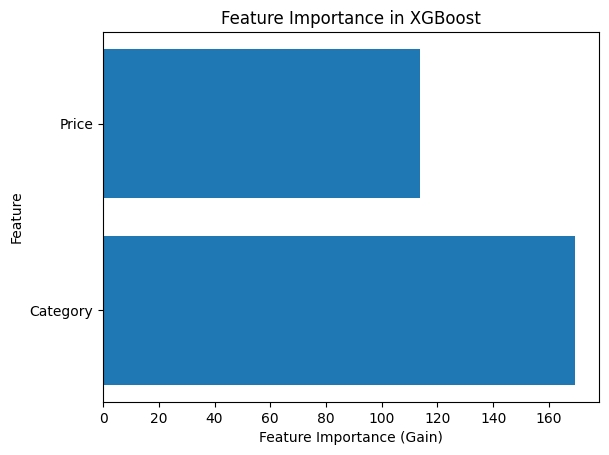

    Feature  Importance
1  Category  169.505844
0     Price  113.732826


In [27]:
xgboostRegressor = xgbRegressorModel(X_train, X_test, y_train, y_test)
xgboostRegressor

## Model Output and Interpretation

The gain is measuring the average improvement of the model's ability to predict the target when a feature is used.

# Combining Features

I want to see if combining all the features that were found to have an impact on the prediction into one model will improve the predictive power.

- create a dataframe with only the features being tested


In [24]:
# dropping the numeric features that were determined not to be relevant to predicting Bike Spots Near
X_Numeric_Values = YCRDataPrepared[['Rating','Rounded Distance_mean']]
X_Numeric_Values

,Rating,Rounded Distance_mean
0,5.0,652.821
1,4.8,673.116
2,4.8,641.800
3,4.8,636.884
4,4.5,718.840
...,...,...
9730,3.3,511.016
9731,3.3,592.194
9732,4.0,858.743
9733,4.0,527.562


In [25]:
# combining all relevant features into one dataframe
X_Combined = pd.concat([X_Numeric_Values, X_Categoric], axis=1)
X_Combined

,Rating,Rounded Distance_mean,Price,Category
0,5.0,652.821,3,79
1,4.8,673.116,0,12
2,4.8,641.800,3,100
3,4.8,636.884,3,100
4,4.5,718.840,0,117
...,...,...,...,...
9730,3.3,511.016,0,92
9731,3.3,592.194,3,100
9732,4.0,858.743,2,115
9733,4.0,527.562,0,57


In [26]:
# splitting the combined data into training and testing
Combined_X_train, Combined_X_test, Combined_y_train, Combined_y_test = train_test_split(X_Combined, y, test_size=0.2, random_state=42)

Showing calculations made with X_train and y_train
R^2: 0.9916965961456299
Adjusted R^2: 0.99169232868894
Mean Squared Error: 0.5092048645019531
Root Mean Squared Error: 0.7135859194953003

Showing calculations made with X_test and y_test
R^2: 0.9836928844451904
Adjusted R^2: 0.9836592961536255
Mean Squared Error: 1.068917989730835
Root Mean Squared Error: 1.0338849015876164

Showing the importance of specific features


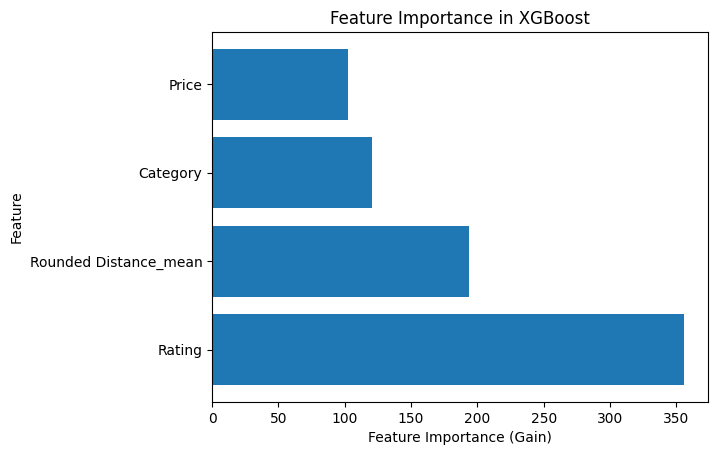

                 Feature  Importance
0                 Rating  356.094513
1  Rounded Distance_mean  193.607025
3               Category  120.435547
2                  Price  102.433777


In [28]:
xgboostRegressorCombined = xgbRegressorModel(Combined_X_train, Combined_X_test, Combined_y_train, Combined_y_test)
xgboostRegressorCombined

## Model Output and Interpretation

In [29]:
# dropping Price to see how much better the model performs
X_Combined_2 = X_Combined.drop(columns=['Price'])
X_Combined_2

,Rating,Rounded Distance_mean,Category
0,5.0,652.821,79
1,4.8,673.116,12
2,4.8,641.800,100
3,4.8,636.884,100
4,4.5,718.840,117
...,...,...,...
9730,3.3,511.016,92
9731,3.3,592.194,100
9732,4.0,858.743,115
9733,4.0,527.562,57


In [30]:
# splitting the combined data into training and testing
Combined_X_2_train, Combined_X_2_test, Combined_y_2_train, Combined_y_2_test = train_test_split(X_Combined_2, y, test_size=0.2, random_state=42)

Showing calculations made with X_train and y_train
R^2: 0.9885444641113281
Adjusted R^2: 0.9885400490795108
Mean Squared Error: 0.7025075554847717
Root Mean Squared Error: 0.8381572379242285

Showing calculations made with X_test and y_test
R^2: 0.9832977652549744
Adjusted R^2: 0.9832719769357592
Mean Squared Error: 1.094815731048584
Root Mean Squared Error: 1.0463344260075667

Showing the importance of specific features


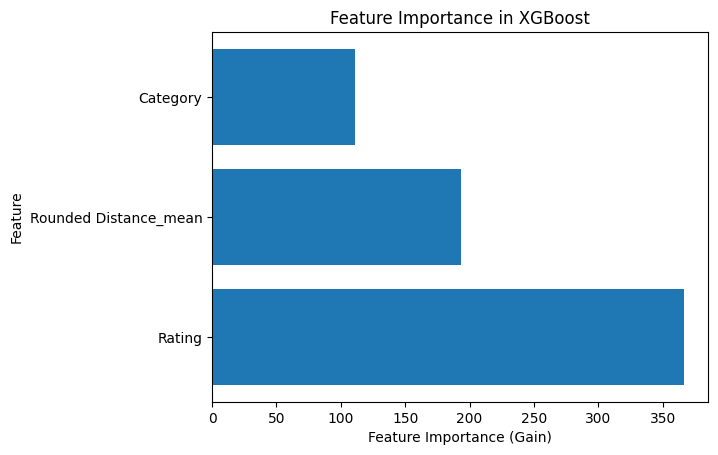

                 Feature  Importance
0                 Rating  366.771240
1  Rounded Distance_mean  193.581451
2               Category  110.747070


In [32]:
xgboostRegressorCombined_2 = xgbRegressorModel(Combined_X_2_train, Combined_X_2_test, Combined_y_2_train, Combined_y_2_test)
xgboostRegressorCombined_2